# **Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import matplotlib.ticker as mticker


pd.set_option('display.max_columns', None)


# **Import Dataset**

In [ ]:
customers = pd.read_csv('/content/customers.csv')
order_items = pd.read_csv('/content/order_items.csv')
payments = pd.read_csv('/content/payments.csv')
orders = pd.read_csv('/content/orders.csv')
products = pd.read_csv('/content/products.csv')
sellers = pd.read_csv('/content/sellers.csv')

# **Merge Dataset**

In [ ]:
df = pd.merge(orders, customers, on='customer_id',how = 'left')
df = pd.merge(df, order_items, on='order_id',how = 'left')
df = pd.merge(df, products, on='product_id',how = 'left')
df = pd.merge(df, sellers, on='seller_id',how = 'left')
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product category,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02,2017-10-02,2017-10-04,2017-10-10,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,housewares,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24,2018-07-26,2018-07-26,2018-08-07,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 3:24:27,118.70,22.76,perfumery,29.0,178.0,1.0,400.0,19.0,13.0,19.0,31570.0,belo horizonte,SP
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08,2018-08-08,2018-08-08,2018-08-17,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 8:55:23,159.90,19.22,automotive,46.0,232.0,1.0,420.0,24.0,19.0,21.0,14840.0,guariba,SP
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18,2017-11-18,2017-11-22,2017-12-02,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet Shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,31842.0,belo horizonte,MG
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13,2018-02-13,2018-02-14,2018-02-16,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,stationary store,38.0,316.0,4.0,250.0,51.0,15.0,15.0,8752.0,mogi das cruzes,SP


# **Data Cleaning**

In [ ]:
df.rename(columns={'order_item_id':'orderd_quantity'},inplace=True)
payments.loc[payments['payment_type'] == 'credit_card', 'payment_type'] = 'credit card'
payments.loc[payments['payment_type'] == 'debit_card', 'payment_type'] = 'debit card'
payments.loc[payments['payment_type'] == 'not_defined', 'payment_type'] = 'not defined'
df.loc[df['orderd_quantity'].isna(),'orderd_quantity'] = df['orderd_quantity'].median()

In [ ]:
df.drop(['order_approved_at','order_delivered_carrier_date',
        'product_description_length','product_photos_qty',
        'product_weight_g','product_length_cm','product_height_cm',
         'product_width_cm'
],axis = 1,inplace=True)

In [ ]:
df['order_purchase_timestamp'] = df['order_purchase_timestamp'].astype('datetime64[ns]')
df['order_delivered_customer_date'] = df['order_delivered_customer_date'].astype('datetime64[ns]')
df['order_estimated_delivery_date'] = df['order_estimated_delivery_date'].astype('datetime64[ns]')
df['orderd_quantity'] = df['orderd_quantity'].astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 21 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       113425 non-null  object        
 1   customer_id                    113425 non-null  object        
 2   order_status                   113425 non-null  object        
 3   order_purchase_timestamp       113425 non-null  datetime64[ns]
 4   order_delivered_customer_date  110196 non-null  datetime64[ns]
 5   order_estimated_delivery_date  113425 non-null  datetime64[ns]
 6   customer_unique_id             113425 non-null  object        
 7   customer_zip_code_prefix       113425 non-null  int64         
 8   customer_city                  113425 non-null  object        
 9   customer_state                 113425 non-null  object        
 10  orderd_quantity                113425 non-null  int64         
 11  

In [ ]:
df.describe()

,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_zip_code_prefix,orderd_quantity,price,freight_value,product_name_length,seller_zip_code_prefix
count,113425,110196,113425,113425.000000,113425.000000,112650.000000,112650.000000,111047.000000,112650.000000
mean,2017-12-30 21:10:51.380207360,2018-01-13 20:41:38.791244800,2018-01-24 08:22:34.875909120,35102.472965,1.196482,120.653739,19.990320,48.775978,24439.170431
min,2016-09-04 00:00:00,2016-10-11 00:00:00,2016-09-30 00:00:00,1003.000000,1.000000,0.850000,0.000000,5.000000,1001.000000
25%,2017-09-13 00:00:00,2017-09-26 00:00:00,2017-10-04 00:00:00,11250.000000,1.000000,39.900000,13.080000,42.000000,6429.000000
50%,2018-01-19 00:00:00,2018-02-02 00:00:00,2018-02-15 00:00:00,24320.000000,1.000000,74.990000,16.260000,52.000000,13568.000000
75%,2018-05-04 00:00:00,2018-05-15 00:00:00,2018-05-25 00:00:00,59020.000000,1.000000,134.900000,21.150000,57.000000,27930.000000
max,2018-10-17 00:00:00,2018-10-17 00:00:00,2018-11-12 00:00:00,99990.000000,21.000000,6735.000000,409.680000,76.000000,99730.000000
std,NaN,NaN,NaN,29864.919733,0.702900,183.633928,15.806405,10.025581,27596.030909


In [ ]:
df['orderd_month_short'] = df['order_purchase_timestamp'].dt.strftime('%b')
df['orderd_month_num'] = df['order_purchase_timestamp'].dt.month
df['orderd_year'] = df['order_purchase_timestamp'].dt.year
df['total_price'] = df['price'] + df['freight_value']

In [ ]:
df['delay_status'] = np.select(
    [df['order_delivered_customer_date'] > df['order_estimated_delivery_date'],
      df['order_delivered_customer_date'] < df['order_estimated_delivery_date']],
    ['Late','Early'],
    default='On Time')

# **Metrics**


In [ ]:
AOV = round(df['total_price'].sum()/df.shape[0],2)
print(f'Average Order Value: {AOV}')

Average Order Value: 139.68


In [ ]:
Total_Revenue = round(df['total_price'].sum(),2)
print(f'Total Revenue: {Total_Revenue}')

Total Revenue: 15843553.24


In [ ]:
Average_order_Quantity = round(df['orderd_quantity'].sum()/df.shape[0])
print(f'Average Order Quantity: {Average_order_Quantity}')

Average Order Quantity: 1


In [ ]:
Average_freight_value = round(df['freight_value'].sum()/df.shape[0])
print(f'Average Freight Value: {Average_freight_value}')

Average Freight Value: 20


#**Visualzation**

## Sales Analysis

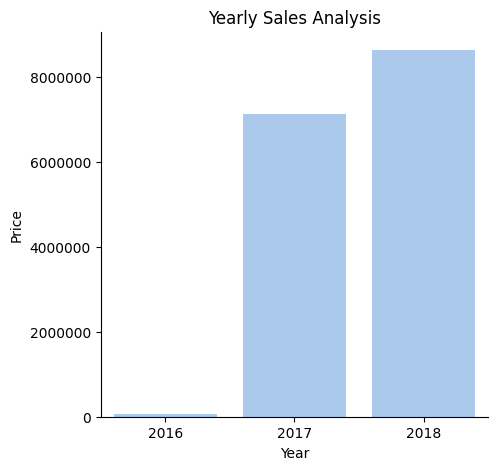

In [ ]:
plt.figure(figsize=(5,5))
data = df.groupby('orderd_year')['total_price'].sum().reset_index()
plt.ticklabel_format(style='plain', axis='y')

sns.barplot(data = data,x = 'orderd_year',y = 'total_price')

plt.xlabel('Year')
plt.ylabel('Price')
plt.title('Yearly Sales Analysis')

sns.despine()
plt.show()

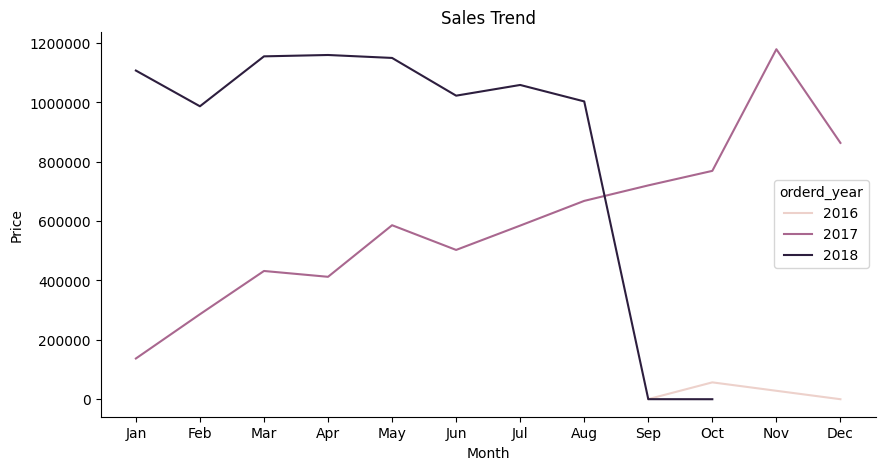

In [ ]:
plt.figure(figsize=(10,5))
data = df.groupby(['orderd_year','orderd_month_short','orderd_month_num'])['total_price'].sum().reset_index()
data = data.sort_values(['orderd_month_num','orderd_year'])

sns.set_palette("pastel")
plt.ticklabel_format(style='plain', axis='y')


sns.lineplot(data = data,x = 'orderd_month_short',y = 'total_price',hue = 'orderd_year')
plt.xlabel('Month')
plt.ylabel('Price')
plt.title('Sales Trend')

sns.despine()
plt.show()

## Payment Analysis

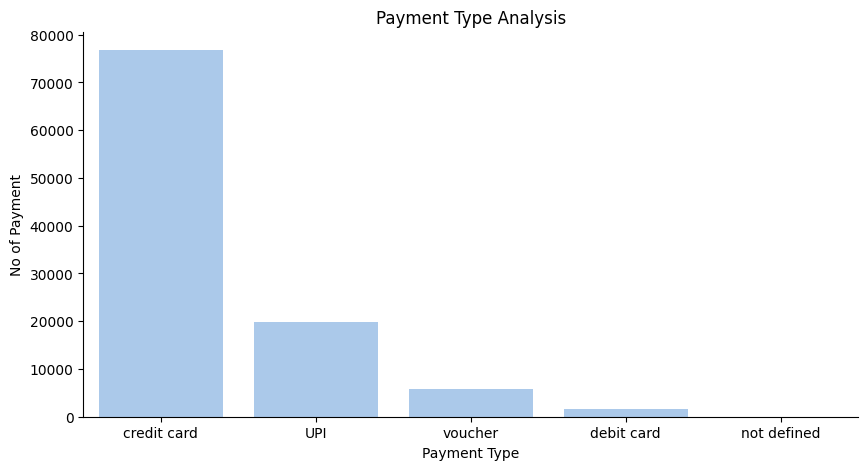

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(data = payments,x = 'payment_type')
plt.xlabel('Payment Type')
plt.ylabel('No of Payment')
plt.title('Payment Type Analysis')

sns.despine()
plt.show()

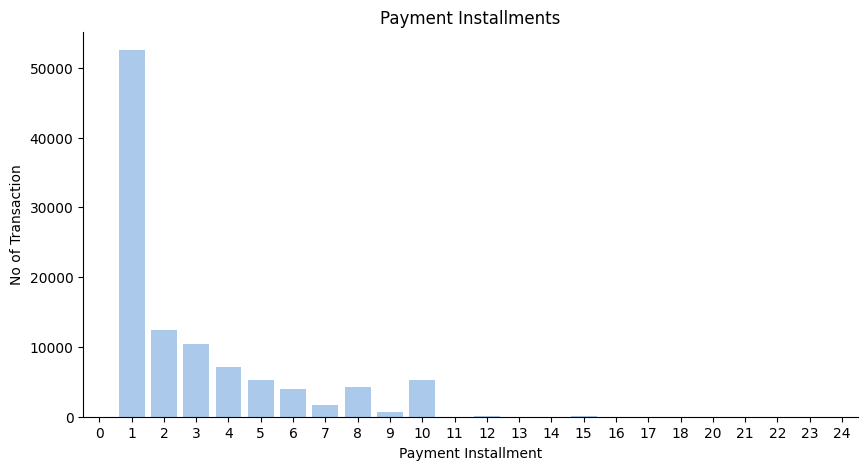

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(data = payments,x = 'payment_installments')
plt.xlabel('Payment Installment')
plt.ylabel('No of Transaction')
plt.title('Payment Installments')

sns.despine()
plt.show()

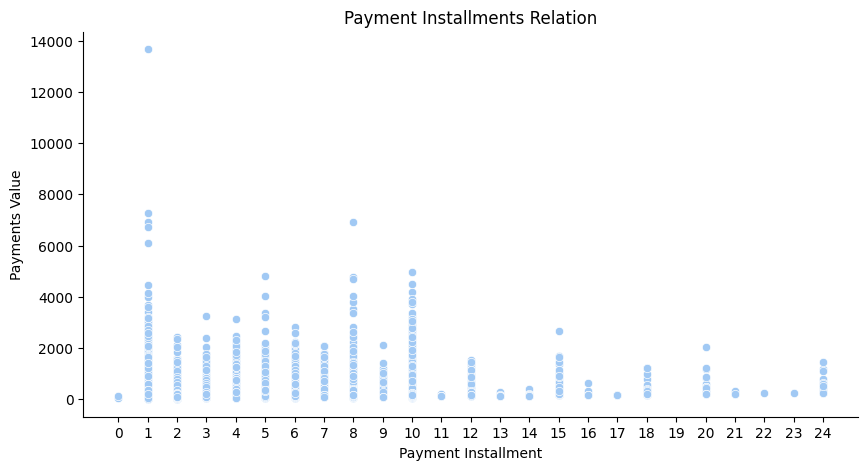

In [ ]:
plt.figure(figsize=(10,5))

sns.scatterplot(data = payments,y = 'payment_value',x = 'payment_installments')

plt.xlabel('Payment Installment')
plt.ylabel('Payments Value')
plt.title('Payment Installments Relation')
plt.xticks(np.arange(0, 25))
sns.despine()
plt.show()

## Sales Volume Analysis

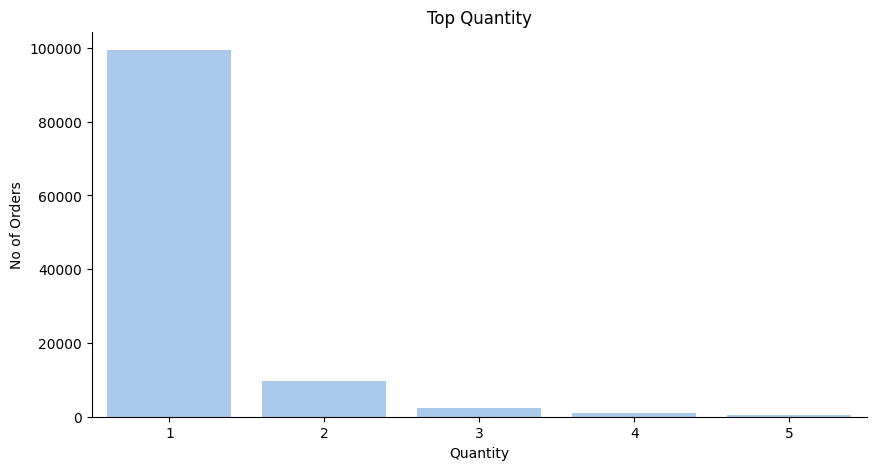

In [ ]:
plt.figure(figsize=(10,5))
top5 = df['orderd_quantity'].value_counts().nlargest(5).index
df_top5 = df[df['orderd_quantity'].isin(top5)]

sns.countplot(data = df_top5,x = 'orderd_quantity')
plt.xlabel('Quantity')
plt.ylabel('No of Orders')
plt.title('Top Quantity')

sns.despine()
plt.show()

## Customer Analysis

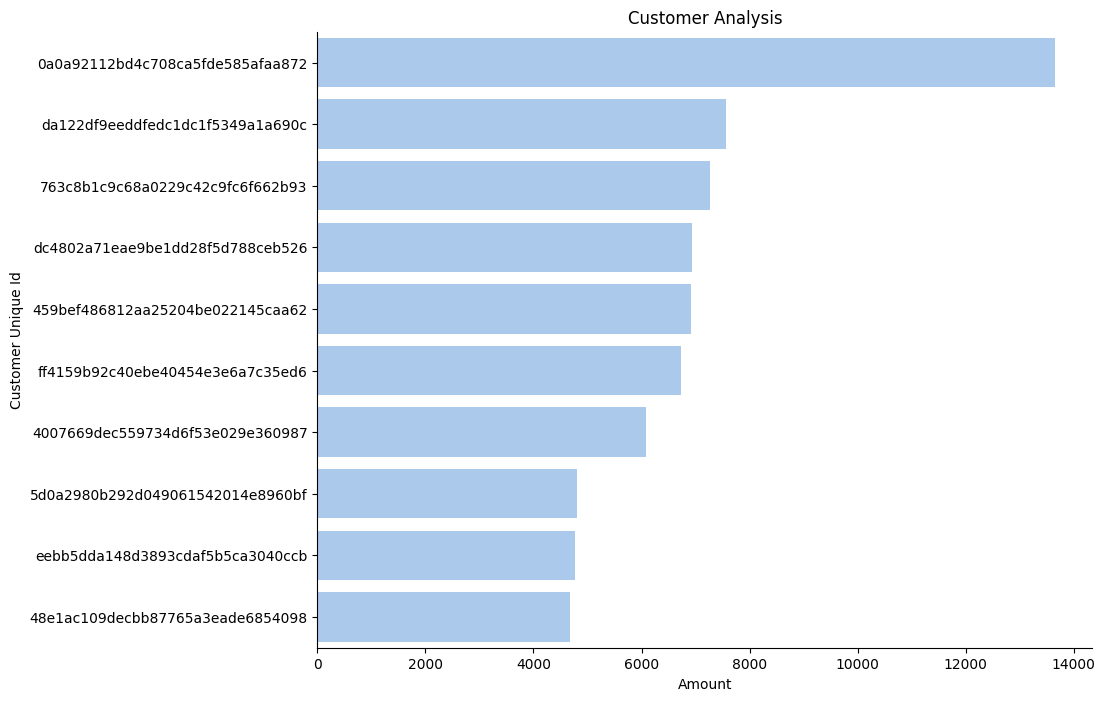

In [ ]:
data = df.groupby('customer_unique_id')['total_price'].sum().sort_values(ascending=False).head(10).reset_index()
plt.figure(figsize=(10,8))
plt.ticklabel_format(style='plain', axis='x')

sns.barplot(data = data , x = 'total_price',y = 'customer_unique_id')

plt.xlabel('Amount')
plt.ylabel('Customer Unique Id')
plt.title('Customer Analysis')
sns.despine()
plt.show()

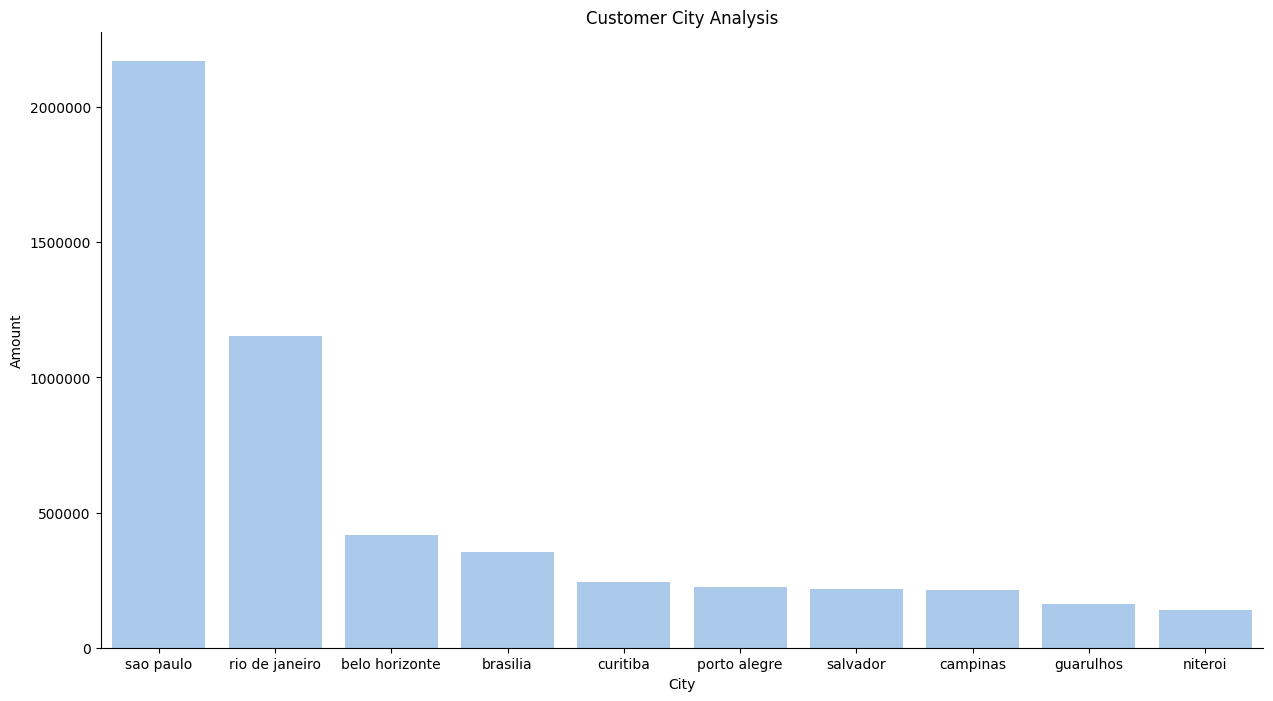

In [ ]:
data = df.groupby('customer_city')['total_price'].sum().sort_values(ascending=False).head(10).reset_index()
plt.figure(figsize=(15,8))
plt.ticklabel_format(style='plain', axis='y')

sns.barplot(data = data , x = 'customer_city',y = 'total_price')

plt.xlabel('City')
plt.ylabel('Amount')
plt.title('Customer City Analysis')
sns.despine()
plt.show()

## Seller Analysis

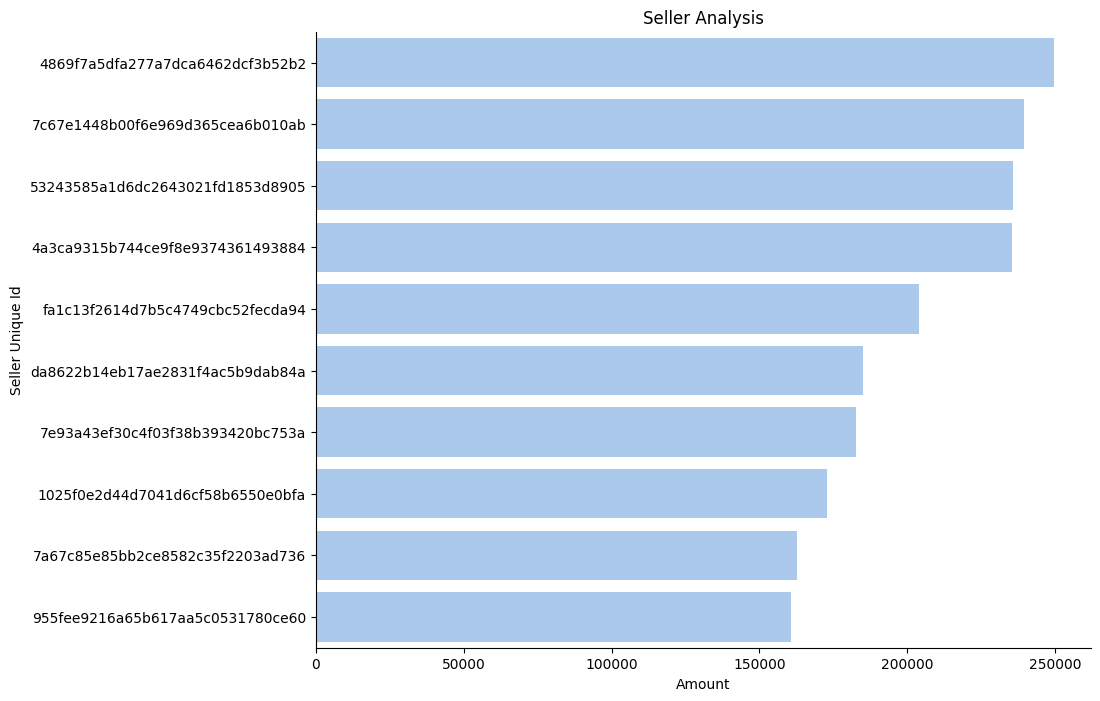

In [ ]:
plt.figure(figsize=(10,8))
data = df.groupby('seller_id')['total_price'].sum().sort_values(ascending=False).head(10).reset_index()

sns.barplot(data = data,y = 'seller_id',x = 'total_price')

plt.xlabel('Amount')
plt.ylabel('Seller Unique Id')
plt.title('Seller Analysis')
sns.despine()
plt.show()

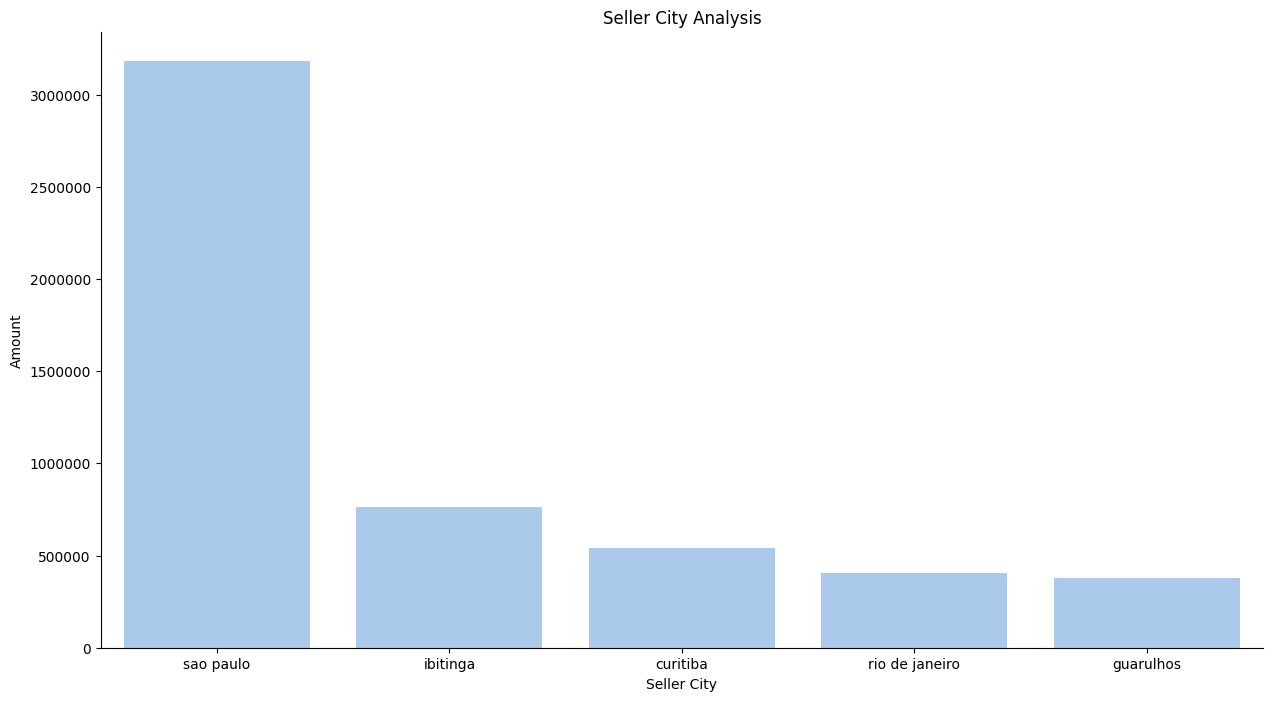

In [ ]:
plt.figure(figsize=(15,8))
data = df.groupby('seller_city')['total_price'].sum().sort_values(ascending=False).head(5).reset_index()

sns.barplot(data = data,x = 'seller_city',y = 'total_price')
plt.ticklabel_format(style='plain', axis='y')

plt.ylabel('Amount')
plt.xlabel('Seller City')
plt.title('Seller City Analysis')
sns.despine()
plt.show()

## Geographic Analysis

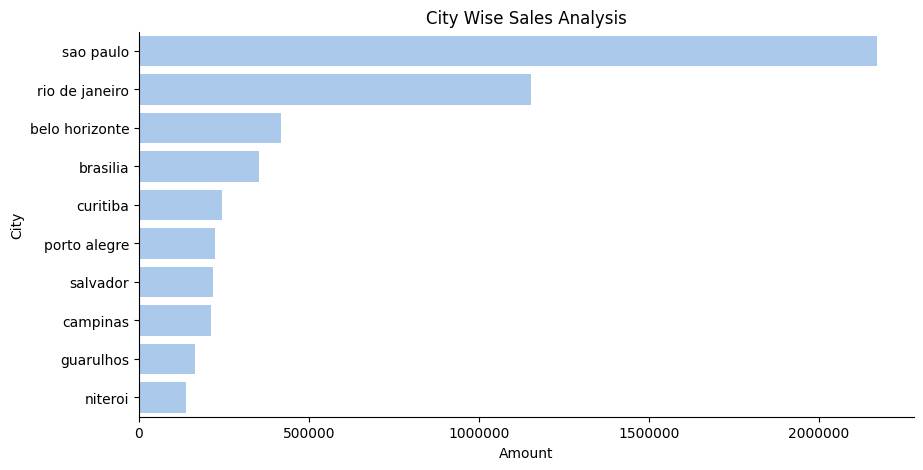

In [ ]:
plt.figure(figsize=(10,5))
data = df.groupby(['customer_city'])['total_price'].sum().reset_index().sort_values('total_price',ascending=False).head(10)

plt.ticklabel_format(style='plain', axis='x')
sns.barplot(data = data,y = 'customer_city',x = 'total_price')

plt.xlabel('Amount')
plt.ylabel('City')
plt.title('City Wise Sales Analysis')

sns.despine()
plt.show()

## Category Analysis

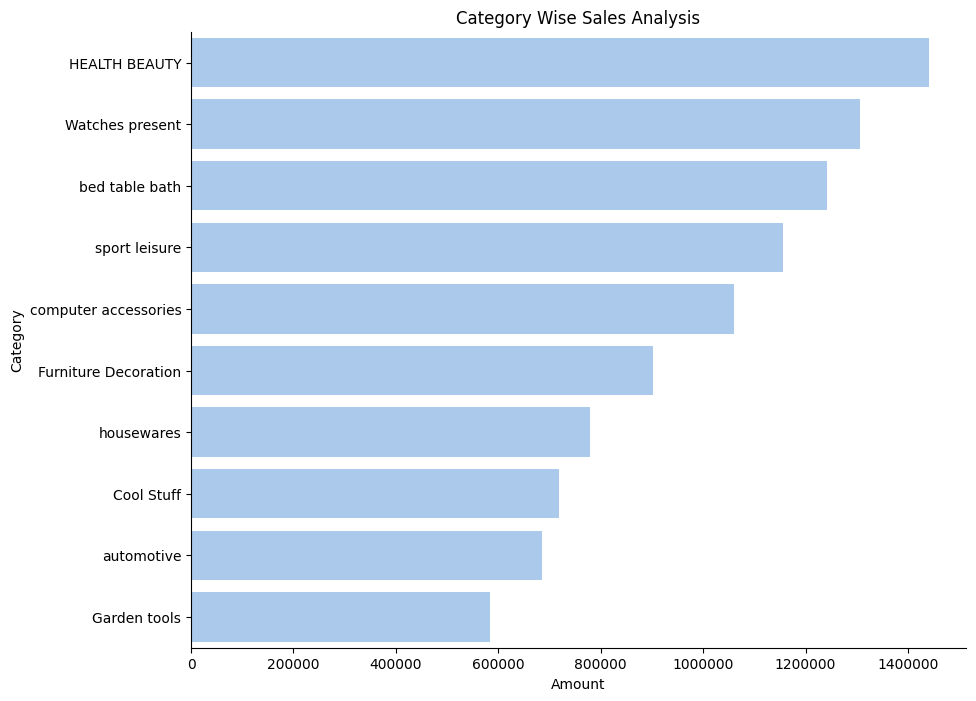

In [ ]:
data = df.groupby('product category')['total_price'].sum().sort_values(ascending=False).head(10).reset_index()
plt.figure(figsize=(10,8))
plt.ticklabel_format(style='plain', axis='x')

sns.barplot(data = data,y = 'product category',x = 'total_price')

plt.xlabel('Amount')
plt.ylabel('Category')
plt.title('Category Wise Sales Analysis')
sns.despine()
plt.show()

## Shipment Delay Status

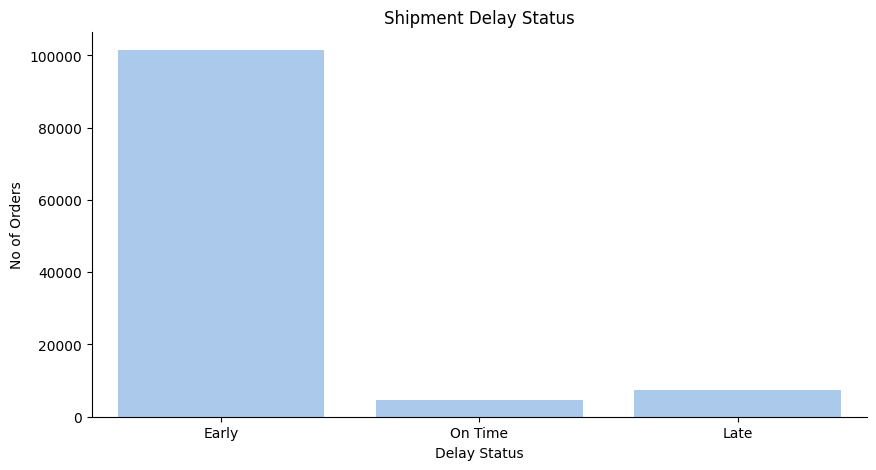

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(data= df,x = 'delay_status')

plt.xlabel('Delay Status')
plt.ylabel('No of Orders')
plt.title('Shipment Delay Status')
sns.despine()
plt.show()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,UPI,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit card,5,369.54
